# Rule-Based Systems in Uncertain Environments  
## Mamdani Fuzzy Inference System

**Target group:** second-year Computer Science students  
**Topic:** rule-based reasoning under uncertainty  
**Model:** Mamdani fuzzy inference with centroid defuzzification

In many real systems, input data is not perfectly precise. Sensors are noisy, human descriptions are vague, and exact thresholds are often artificial.  
A fuzzy rule-based system handles this by using linguistic values such as **low visibility**, **close obstacle**, or **safe speed**, instead of only strict Boolean conditions.

In this lab, you will build a small Mamdani fuzzy inference system for an autonomous delivery robot.

## Problem statement

An autonomous delivery robot must decide its recommended driving speed in an uncertain environment.

The robot receives three uncertain input values:

1. **Visibility**: from 0 to 100 percent  
2. **Obstacle distance**: from 0 to 10 meters  
3. **Battery level**: from 0 to 100 percent  

The system must output one crisp value:

4. **Recommended speed**: from 0 to 10 km/h  

Because the environment is uncertain, we do not use rigid rules such as:

```text
IF visibility < 40 THEN speed = 2
```

Instead, we use fuzzy rules such as:

```text
IF visibility is low OR obstacle distance is close THEN speed is very slow
```

At the end, the fuzzy output will be converted into a crisp speed using the **centroid method**.

## Learning objectives

After completing this notebook, you should be able to:

- define fuzzy membership functions;
- fuzzify crisp sensor inputs;
- encode linguistic IF–THEN rules;
- apply Mamdani inference using `min` and `max`;
- aggregate fuzzy conclusions;
- compute a crisp output using centroid defuzzification;
- test how rule-based systems behave under uncertainty.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Membership functions

We define two basic membership functions:

- triangular membership function;
- trapezoidal membership function.

A membership function maps a crisp value to a degree between 0 and 1.

For example, a visibility value of 35% may belong to the fuzzy set `low visibility` with degree 0.6 and to the fuzzy set `medium visibility` with degree 0.4.

In [2]:
def triangular(x, a, b, c):
    """
    Triangular membership function.

    Parameters:
    x : array-like
        Universe of discourse.
    a, b, c : float
        Triangle parameters, where a <= b <= c.

    Returns:
    array-like
        Membership degree for each x.
    """
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)

    if a != b:
        left = (x >= a) & (x <= b)
        y[left] = (x[left] - a) / (b - a)

    if b != c:
        right = (x >= b) & (x <= c)
        y[right] = (c - x[right]) / (c - b)

    y[x == b] = 1.0
    return np.clip(y, 0, 1)


def trapezoidal(x, a, b, c, d):
    """
    Trapezoidal membership function.

    Parameters:
    x : array-like
        Universe of discourse.
    a, b, c, d : float
        Trapezoid parameters, where a <= b <= c <= d.

    Returns:
    array-like
        Membership degree for each x.
    """
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)

    if a != b:
        rising = (x >= a) & (x <= b)
        y[rising] = (x[rising] - a) / (b - a)

    plateau = (x >= b) & (x <= c)
    y[plateau] = 1.0

    if c != d:
        falling = (x >= c) & (x <= d)
        y[falling] = (d - x[falling]) / (d - c)

    return np.clip(y, 0, 1)


def membership_at(value, universe, membership_values):
    """
    Interpolates the membership degree of a crisp value
    in a fuzzy set defined over a universe.
    """
    return np.interp(value, universe, membership_values)

## 2. Define the universes of discourse

Each variable has a numerical range.

The resolution is chosen fine enough for plotting and centroid computation.

In [3]:
visibility = np.linspace(0, 100, 501)       # percentage
distance = np.linspace(0, 10, 501)          # meters
battery = np.linspace(0, 100, 501)          # percentage
speed = np.linspace(0, 10, 501)             # km/h

## 3. Define fuzzy sets

We now define linguistic values for each variable.

### Input 1: Visibility

- low
- medium
- high

### Input 2: Obstacle distance

- close
- medium
- far

### Input 3: Battery level

- low
- medium
- high

### Output: Recommended speed

- very slow
- slow
- moderate
- fast

In [4]:
visibility_sets = {
    "low": trapezoidal(visibility, 0, 0, 20, 45),
    "medium": triangular(visibility, 25, 50, 75),
    "high": trapezoidal(visibility, 55, 80, 100, 100)
}

distance_sets = {
    "close": trapezoidal(distance, 0, 0, 1.5, 3.5),
    "medium": triangular(distance, 2, 5, 8),
    "far": trapezoidal(distance, 6, 8, 10, 10)
}

battery_sets = {
    "low": trapezoidal(battery, 0, 0, 20, 40),
    "medium": triangular(battery, 25, 50, 75),
    "high": trapezoidal(battery, 60, 80, 100, 100)
}

speed_sets = {
    "very_slow": trapezoidal(speed, 0, 0, 1, 2.5),
    "slow": triangular(speed, 1.5, 3, 4.5),
    "moderate": triangular(speed, 3.5, 5.5, 7.5),
    "fast": trapezoidal(speed, 6.5, 8, 10, 10)
}

## 4. Visualize the fuzzy sets

The plots below show how crisp numerical values are mapped into linguistic categories.

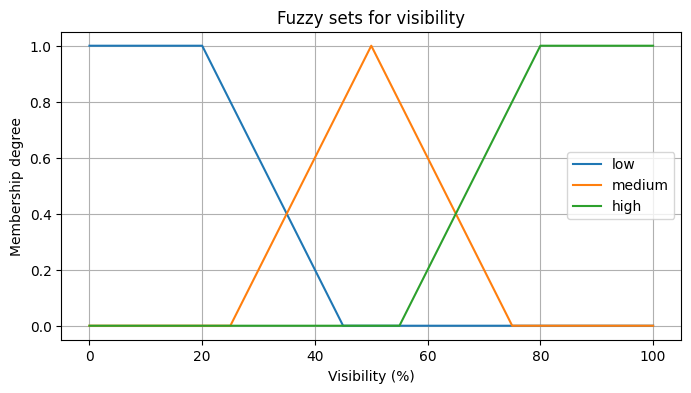

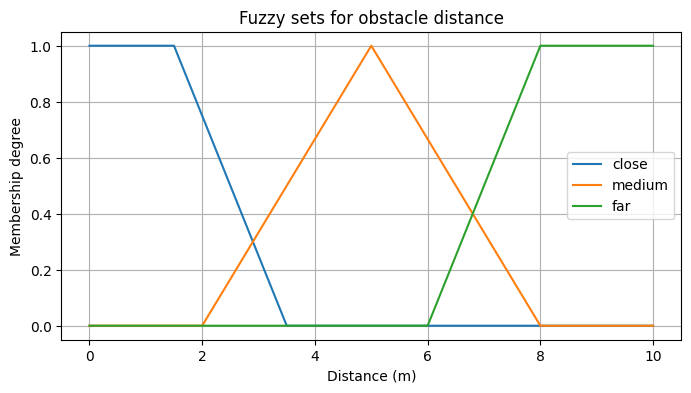

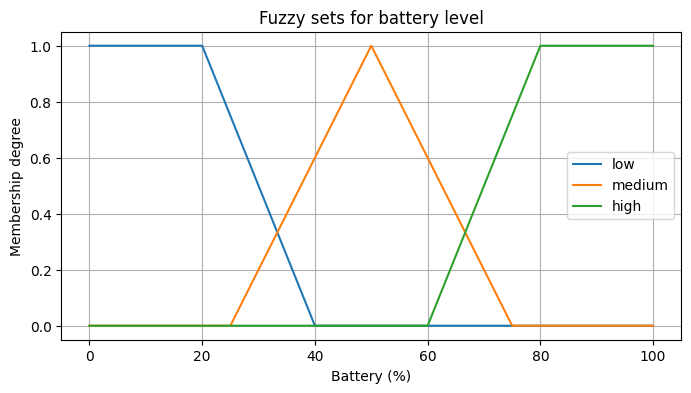

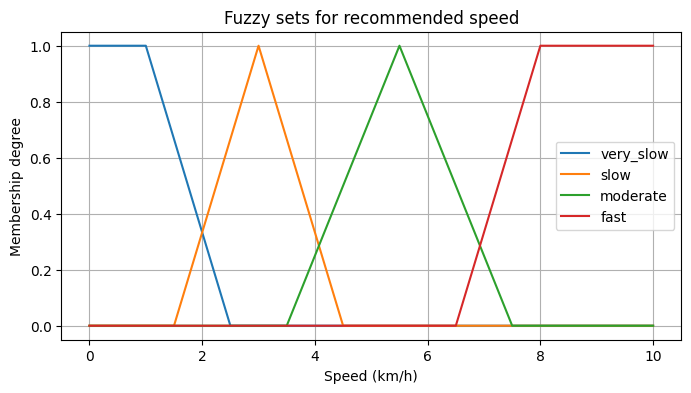

In [5]:
def plot_sets(universe, sets, title, xlabel):
    plt.figure(figsize=(8, 4))
    for name, values in sets.items():
        plt.plot(universe, values, label=name)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Membership degree")
    plt.ylim(-0.05, 1.05)
    plt.grid(True)
    plt.legend()
    plt.show()


plot_sets(visibility, visibility_sets, "Fuzzy sets for visibility", "Visibility (%)")
plot_sets(distance, distance_sets, "Fuzzy sets for obstacle distance", "Distance (m)")
plot_sets(battery, battery_sets, "Fuzzy sets for battery level", "Battery (%)")
plot_sets(speed, speed_sets, "Fuzzy sets for recommended speed", "Speed (km/h)")

## 5. Fuzzification

Fuzzification transforms crisp inputs into fuzzy membership degrees.

We will test the system with this situation:

```text
visibility = 42%
obstacle distance = 3.2 m
battery = 65%
```

These values are not extreme. The robot has partial visibility, the obstacle is not very close but not far either, and the battery is acceptable.

In [6]:
input_visibility = 42
input_distance = 3.2
input_battery = 65

fuzzified_visibility = {
    name: membership_at(input_visibility, visibility, values)
    for name, values in visibility_sets.items()
}

fuzzified_distance = {
    name: membership_at(input_distance, distance, values)
    for name, values in distance_sets.items()
}

fuzzified_battery = {
    name: membership_at(input_battery, battery, values)
    for name, values in battery_sets.items()
}

print("Fuzzified visibility:", fuzzified_visibility)
print("Fuzzified distance:", fuzzified_distance)
print("Fuzzified battery:", fuzzified_battery)

Fuzzified visibility: {'low': np.float64(0.12), 'medium': np.float64(0.68), 'high': np.float64(0.0)}
Fuzzified distance: {'close': np.float64(0.1499999999999999), 'medium': np.float64(0.4000000000000001), 'far': np.float64(0.0)}
Fuzzified battery: {'low': np.float64(0.0), 'medium': np.float64(0.4), 'high': np.float64(0.25)}


## 6. Rule base

We define a small rule base.

The logical operators are implemented as follows:

- `AND` is modeled by `min`;
- `OR` is modeled by `max`;
- implication is modeled by clipping the output fuzzy set with `min`;
- aggregation is modeled by `max`.

This is a common Mamdani-style fuzzy inference pipeline.

### Rules

1. IF visibility is low OR obstacle distance is close THEN speed is very slow  
2. IF visibility is medium AND obstacle distance is close THEN speed is very slow  
3. IF visibility is medium AND obstacle distance is medium THEN speed is slow  
4. IF visibility is high AND obstacle distance is medium THEN speed is moderate  
5. IF visibility is high AND obstacle distance is far AND battery is high THEN speed is fast  
6. IF battery is low AND obstacle distance is far THEN speed is moderate  
7. IF battery is low AND obstacle distance is close THEN speed is very slow  
8. IF visibility is medium AND battery is medium AND obstacle distance is far THEN speed is moderate

In [7]:
def fuzzy_and(*values):
    return np.min(values)


def fuzzy_or(*values):
    return np.max(values)


def apply_rule(strength, output_set):
    """
    Mamdani implication: clip the consequent fuzzy set
    at the rule activation strength.
    """
    return np.minimum(strength, output_set)


def aggregate_outputs(*outputs):
    """
    Mamdani aggregation: combine all clipped consequents using max.
    """
    return np.maximum.reduce(outputs)


def centroid_defuzzification(universe, aggregated_membership):
    """
    Computes the crisp value using the centroid method.

    crisp_value = sum(x * mu(x)) / sum(mu(x))
    """
    denominator = np.sum(aggregated_membership)

    if denominator == 0:
        return np.nan

    return np.sum(universe * aggregated_membership) / denominator

## 7. Mamdani inference function

The function below executes the full fuzzy inference pipeline:

1. fuzzify the crisp inputs;
2. compute rule activation strengths;
3. clip each consequent fuzzy set;
4. aggregate the clipped outputs;
5. defuzzify the result using centroid.

In [8]:
def mamdani_robot_speed(input_visibility, input_distance, input_battery, verbose=True):
    # Fuzzification
    V = {
        name: membership_at(input_visibility, visibility, values)
        for name, values in visibility_sets.items()
    }

    D = {
        name: membership_at(input_distance, distance, values)
        for name, values in distance_sets.items()
    }

    B = {
        name: membership_at(input_battery, battery, values)
        for name, values in battery_sets.items()
    }

    # Rule activation strengths
    rules = []

    strength = fuzzy_or(V["low"], D["close"])
    rules.append(("R1: low visibility OR close obstacle -> very slow", strength, "very_slow"))

    strength = fuzzy_and(V["medium"], D["close"])
    rules.append(("R2: medium visibility AND close obstacle -> very slow", strength, "very_slow"))

    strength = fuzzy_and(V["medium"], D["medium"])
    rules.append(("R3: medium visibility AND medium obstacle -> slow", strength, "slow"))

    strength = fuzzy_and(V["high"], D["medium"])
    rules.append(("R4: high visibility AND medium obstacle -> moderate", strength, "moderate"))

    strength = fuzzy_and(V["high"], D["far"], B["high"])
    rules.append(("R5: high visibility AND far obstacle AND high battery -> fast", strength, "fast"))

    strength = fuzzy_and(B["low"], D["far"])
    rules.append(("R6: low battery AND far obstacle -> moderate", strength, "moderate"))

    strength = fuzzy_and(B["low"], D["close"])
    rules.append(("R7: low battery AND close obstacle -> very slow", strength, "very_slow"))

    strength = fuzzy_and(V["medium"], B["medium"], D["far"])
    rules.append(("R8: medium visibility AND medium battery AND far obstacle -> moderate", strength, "moderate"))

    # Apply Mamdani implication
    clipped_outputs = []
    for _, strength, consequent_name in rules:
        clipped_outputs.append(apply_rule(strength, speed_sets[consequent_name]))

    # Aggregate all rule conclusions
    aggregated = aggregate_outputs(*clipped_outputs)

    # Defuzzification
    crisp_speed = centroid_defuzzification(speed, aggregated)

    if verbose:
        print("Input values")
        print(f"  Visibility: {input_visibility}%")
        print(f"  Obstacle distance: {input_distance} m")
        print(f"  Battery level: {input_battery}%")
        print()

        print("Fuzzified inputs")
        print("  Visibility:", V)
        print("  Distance:", D)
        print("  Battery:", B)
        print()

        print("Rule activations")
        for rule_text, strength, consequent_name in rules:
            print(f"  {rule_text}: strength = {strength:.3f}")

        print()
        print(f"Crisp recommended speed: {crisp_speed:.2f} km/h")

    return crisp_speed, aggregated, rules

## 8. Run the system on the example case

In [9]:
crisp_speed, aggregated_output, rules = mamdani_robot_speed(
    input_visibility=42,
    input_distance=3.2,
    input_battery=65
)

Input values
  Visibility: 42%
  Obstacle distance: 3.2 m
  Battery level: 65%

Fuzzified inputs
  Visibility: {'low': np.float64(0.12), 'medium': np.float64(0.68), 'high': np.float64(0.0)}
  Distance: {'close': np.float64(0.1499999999999999), 'medium': np.float64(0.4000000000000001), 'far': np.float64(0.0)}
  Battery: {'low': np.float64(0.0), 'medium': np.float64(0.4), 'high': np.float64(0.25)}

Rule activations
  R1: low visibility OR close obstacle -> very slow: strength = 0.150
  R2: medium visibility AND close obstacle -> very slow: strength = 0.150
  R3: medium visibility AND medium obstacle -> slow: strength = 0.400
  R4: high visibility AND medium obstacle -> moderate: strength = 0.000
  R5: high visibility AND far obstacle AND high battery -> fast: strength = 0.000
  R6: low battery AND far obstacle -> moderate: strength = 0.000
  R7: low battery AND close obstacle -> very slow: strength = 0.000
  R8: medium visibility AND medium battery AND far obstacle -> moderate: strength 

## 9. Visualize the final aggregated fuzzy output

The vertical dashed line marks the crisp speed obtained with centroid defuzzification.

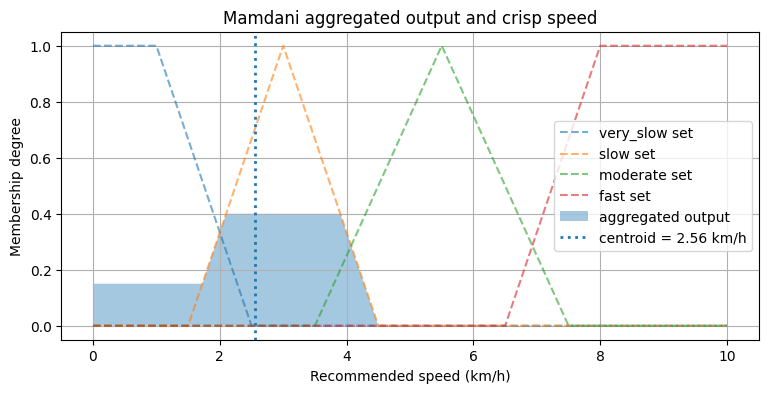

In [10]:
plt.figure(figsize=(9, 4))

for name, values in speed_sets.items():
    plt.plot(speed, values, linestyle="--", alpha=0.6, label=f"{name} set")

plt.fill_between(speed, aggregated_output, alpha=0.4, label="aggregated output")
plt.axvline(crisp_speed, linestyle=":", linewidth=2, label=f"centroid = {crisp_speed:.2f} km/h")

plt.title("Mamdani aggregated output and crisp speed")
plt.xlabel("Recommended speed (km/h)")
plt.ylabel("Membership degree")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

## 10. Test several uncertain situations

Now we compare multiple scenarios.

Each row contains:

```text
visibility, obstacle distance, battery
```

In [11]:
test_cases = [
    (20, 1.0, 90),   # poor visibility, close obstacle, high battery
    (90, 9.0, 90),   # excellent situation
    (70, 4.0, 30),   # acceptable visibility, medium obstacle, low battery
    (45, 7.5, 55),   # medium visibility, far obstacle, medium battery
    (80, 2.0, 80),   # high visibility but close obstacle
    (30, 8.0, 20),   # low visibility, far obstacle, low battery
]

results = []

for v, d, b in test_cases:
    crisp, _, _ = mamdani_robot_speed(v, d, b, verbose=False)
    results.append((v, d, b, crisp))

print("Visibility | Distance | Battery | Recommended speed")
print("-" * 52)
for v, d, b, crisp in results:
    print(f"{v:10.1f} | {d:8.1f} | {b:7.1f} | {crisp:17.2f}")

Visibility | Distance | Battery | Recommended speed
----------------------------------------------------
      20.0 |      1.0 |    90.0 |              0.92
      90.0 |      9.0 |    90.0 |              8.60
      70.0 |      4.0 |    30.0 |              4.95
      45.0 |      7.5 |    55.0 |              5.06
      80.0 |      2.0 |    80.0 |              0.99
      30.0 |      8.0 |    20.0 |              3.80


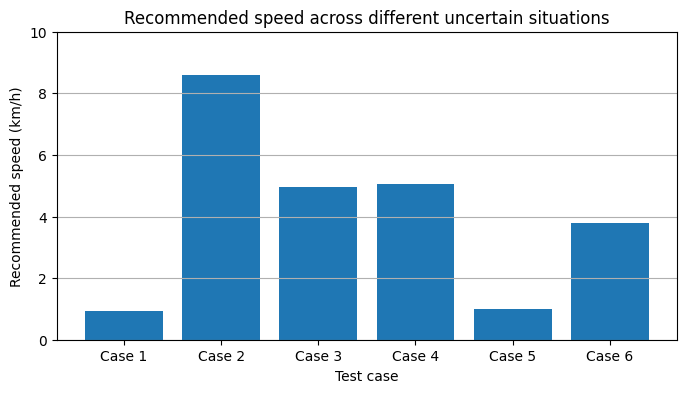

In [12]:
plt.figure(figsize=(8, 4))

labels = [f"Case {i+1}" for i in range(len(results))]
speeds = [row[3] for row in results]

plt.bar(labels, speeds)
plt.title("Recommended speed across different uncertain situations")
plt.xlabel("Test case")
plt.ylabel("Recommended speed (km/h)")
plt.ylim(0, 10)
plt.grid(axis="y")
plt.show()

## 11. Student task 1: add a new rule

Add the following rule to the system:

```text
IF visibility is high AND battery is low AND obstacle distance is far THEN speed is moderate
```

Question:  
Does this rule change the result for the case below?

```text
visibility = 85
obstacle distance = 9
battery = 25
```

Explain why.

In [13]:
# TODO:
# 1. Copy the mamdani_robot_speed function.
# 2. Add the new rule.
# 3. Run the function for:
#       visibility = 85
#       obstacle distance = 9
#       battery = 25
# 4. Compare the new crisp output with the old crisp output.

def mamdani_robot_speed_v2(input_visibility, input_distance, input_battery, verbose=True):
    # Fuzzification
    V = {
        name: membership_at(input_visibility, visibility, values)
        for name, values in visibility_sets.items()
    }

    D = {
        name: membership_at(input_distance, distance, values)
        for name, values in distance_sets.items()
    }

    B = {
        name: membership_at(input_battery, battery, values)
        for name, values in battery_sets.items()
    }

    # Rule activation strengths
    rules = []

    strength = fuzzy_or(V["low"], D["close"])
    rules.append(("R1: low visibility OR close obstacle -> very slow", strength, "very_slow"))

    strength = fuzzy_and(V["medium"], D["close"])
    rules.append(("R2: medium visibility AND close obstacle -> very slow", strength, "very_slow"))

    strength = fuzzy_and(V["medium"], D["medium"])
    rules.append(("R3: medium visibility AND medium obstacle -> slow", strength, "slow"))

    strength = fuzzy_and(V["high"], D["medium"])
    rules.append(("R4: high visibility AND medium obstacle -> moderate", strength, "moderate"))

    strength = fuzzy_and(V["high"], D["far"], B["high"])
    rules.append(("R5: high visibility AND far obstacle AND high battery -> fast", strength, "fast"))

    strength = fuzzy_and(B["low"], D["far"])
    rules.append(("R6: low battery AND far obstacle -> moderate", strength, "moderate"))

    strength = fuzzy_and(B["low"], D["close"])
    rules.append(("R7: low battery AND close obstacle -> very slow", strength, "very_slow"))

    strength = fuzzy_and(V["medium"], B["medium"], D["far"])
    rules.append(("R8: medium visibility AND medium battery AND far obstacle -> moderate", strength, "moderate"))

    # NEW RULE
    strength = fuzzy_and(V["high"], B["low"], D["far"])
    rules.append(("R9: high visibility AND low battery AND far obstacle -> moderate", strength, "moderate"))

    # Apply Mamdani implication
    clipped_outputs = []
    for _, strength, consequent_name in rules:
        clipped_outputs.append(apply_rule(strength, speed_sets[consequent_name]))

    # Aggregate all rule conclusions
    aggregated = aggregate_outputs(*clipped_outputs)

    # Defuzzification
    crisp_speed = centroid_defuzzification(speed, aggregated)

    if verbose:
        print("Input values")
        print(f"  Visibility: {input_visibility}%")
        print(f"  Obstacle distance: {input_distance} m")
        print(f"  Battery level: {input_battery}%")
        print()

        print("Fuzzified inputs")
        print("  Visibility:", V)
        print("  Distance:", D)
        print("  Battery:", B)
        print()

        print("Rule activations")
        for rule_text, strength, consequent_name in rules:
            print(f"  {rule_text}: strength = {strength:.3f}")

        print()
        print(f"Crisp recommended speed: {crisp_speed:.2f} km/h")

    return crisp_speed, aggregated, rules


old_crisp, _, _ = mamdani_robot_speed(85, 9, 25, verbose=True)
print()
new_crisp, _, _ = mamdani_robot_speed_v2(85, 9, 25, verbose=True)
print()
print(f"Old crisp speed: {old_crisp:.2f} km/h")
print(f"New crisp speed: {new_crisp:.2f} km/h")
print(f"Difference: {abs(new_crisp - old_crisp):.4f} km/h")

Input values
  Visibility: 85%
  Obstacle distance: 9 m
  Battery level: 25%

Fuzzified inputs
  Visibility: {'low': np.float64(0.0), 'medium': np.float64(0.0), 'high': np.float64(1.0)}
  Distance: {'close': np.float64(0.0), 'medium': np.float64(0.0), 'far': np.float64(1.0)}
  Battery: {'low': np.float64(0.75), 'medium': np.float64(0.0), 'high': np.float64(0.0)}

Rule activations
  R1: low visibility OR close obstacle -> very slow: strength = 0.000
  R2: medium visibility AND close obstacle -> very slow: strength = 0.000
  R3: medium visibility AND medium obstacle -> slow: strength = 0.000
  R4: high visibility AND medium obstacle -> moderate: strength = 0.000
  R5: high visibility AND far obstacle AND high battery -> fast: strength = 0.000
  R6: low battery AND far obstacle -> moderate: strength = 0.750
  R7: low battery AND close obstacle -> very slow: strength = 0.000
  R8: medium visibility AND medium battery AND far obstacle -> moderate: strength = 0.000

Crisp recommended speed: 

Does this rule change the result for the case below?

No, the new rule does not change the result.
R9 fires at strength min(1.0, 0.75, 1.0) = 0.75 and maps to moderate, but R6 already fires at the same strength 0.75 with the same consequent. 
Since aggregation takes the max, the aggregated output is identical and the crisp speed doesn't change.

## 12. Student task 2: change the shape of a fuzzy set

Modify the fuzzy set `close obstacle`.

Original version:

```python
"close": trapezoidal(distance, 0, 0, 1.5, 3.5)
```

Try this version:

```python
"close": trapezoidal(distance, 0, 0, 2.5, 5.0)
```

Question:

What happens to the recommended speed when the obstacle distance is around 4 meters?

This is an important issue in rule-based systems: the final decision is strongly affected by how linguistic categories are defined.

In [14]:
# TODO:
# Modify distance_sets["close"] and rerun the system for:
# visibility = 70
# obstacle distance = 4
# battery = 80

# Example:
# distance_sets["close"] = trapezoidal(distance, 0, 0, 2.5, 5.0)
# crisp, aggregated, rules = mamdani_robot_speed(70, 4, 80)

# Original distance_sets["close"]
distance_sets["close"] = trapezoidal(distance, 0, 0, 1.5, 3.5)
original_crisp, _, _ = mamdani_robot_speed(70, 4, 80, verbose=False)

# Modified distance_sets["close"]
distance_sets["close"] = trapezoidal(distance, 0, 0, 2.5, 5.0)
modified_crisp, _, _ = mamdani_robot_speed(70, 4, 80, verbose=True)

# Restore original
distance_sets["close"] = trapezoidal(distance, 0, 0, 1.5, 3.5)

print(f"Original crisp speed: {original_crisp:.2f} km/h")
print(f"Modified crisp speed: {modified_crisp:.2f} km/h")
print(f"Difference: {abs(modified_crisp - original_crisp):.4f} km/h")


Input values
  Visibility: 70%
  Obstacle distance: 4 m
  Battery level: 80%

Fuzzified inputs
  Visibility: {'low': np.float64(0.0), 'medium': np.float64(0.2), 'high': np.float64(0.6)}
  Distance: {'close': np.float64(0.4), 'medium': np.float64(0.6666666666666666), 'far': np.float64(0.0)}
  Battery: {'low': np.float64(0.0), 'medium': np.float64(0.0), 'high': np.float64(1.0)}

Rule activations
  R1: low visibility OR close obstacle -> very slow: strength = 0.400
  R2: medium visibility AND close obstacle -> very slow: strength = 0.200
  R3: medium visibility AND medium obstacle -> slow: strength = 0.200
  R4: high visibility AND medium obstacle -> moderate: strength = 0.600
  R5: high visibility AND far obstacle AND high battery -> fast: strength = 0.000
  R6: low battery AND far obstacle -> moderate: strength = 0.000
  R7: low battery AND close obstacle -> very slow: strength = 0.000
  R8: medium visibility AND medium battery AND far obstacle -> moderate: strength = 0.000

Crisp recom

What happens to the recommended speed when the obstacle distance is around 4 meters?

With the original definition, 4 meters has zero membership in close, so only R4 fires strongly and the speed is moderate. 
With the wider definition, 4 meters gets a 0.4 membership in close, which activates R1 and pulls the output 
toward very slow, lowering the recommended speed.

## 13. Student task 3: compare Mamdani with a crisp rule system

Write a simple crisp rule-based system using `if`, `elif`, and `else`.

For example:

```text
IF visibility < 40 OR obstacle_distance < 3 THEN speed = 2
ELSE IF visibility > 70 AND obstacle_distance > 7 AND battery > 60 THEN speed = 8
ELSE speed = 5
```

Then compare the crisp rule-based system with the Mamdani fuzzy system.

Questions:

1. Which system changes more smoothly when inputs change?
2. Which system is easier to interpret?
3. Which system is more sensitive to threshold choices?
4. In what real-world situations would the fuzzy system be more appropriate?

In [15]:
def crisp_rule_robot_speed(input_visibility, input_distance, input_battery):
    if input_visibility < 40 or input_distance < 3:
        return 2.0
    elif input_visibility > 70 and input_distance > 7 and input_battery > 60:
        return 8.0
    elif input_battery < 30:
        return 4.0
    else:
        return 5.0


comparison_cases = [
    (39, 5, 80),
    (40, 5, 80),
    (41, 5, 80),
    (75, 7.1, 80),
    (75, 6.9, 80),
]

print("Visibility | Distance | Battery | Crisp rules | Mamdani")
print("-" * 62)

for v, d, b in comparison_cases:
    crisp_rule_value = crisp_rule_robot_speed(v, d, b)
    mamdani_value, _, _ = mamdani_robot_speed(v, d, b, verbose=False)
    print(f"{v:10.1f} | {d:8.1f} | {b:7.1f} | {crisp_rule_value:11.2f} | {mamdani_value:7.2f}")

Visibility | Distance | Battery | Crisp rules | Mamdani
--------------------------------------------------------------
      39.0 |      5.0 |    80.0 |        2.00 |    2.46
      40.0 |      5.0 |    80.0 |        5.00 |    2.55
      41.0 |      5.0 |    80.0 |        5.00 |    2.63
      75.0 |      7.1 |    80.0 |        8.00 |    7.37
      75.0 |      6.9 |    80.0 |        5.00 |    7.09


1. Which system changes more smoothly when inputs change?

Mamdani. The comparison cases show that the crisp system jumps from 2.0 to 5.0 between visibility 39 and 40, while Mamdani transitions gradually because membership functions allow partial activation.

2. Which system is easier to interpret?

The crisp system. The rules are straightforward if/elif conditions that are easy to read and reason about without any knowledge of fuzzy logic.

3. Which system is more sensitive to threshold choices?

The crisp system. A single threshold like visibility < 40 causes a hard jump in output. In Mamdani, shifting a boundary in a membership function changes the output gradually.

4. In what real-world situations would the fuzzy system be more appropriate?

Any situation where sensor data is noisy or imprecise and abrupt output changes would be dangerous, for example autonomous vehicles, medical monitoring, or climate control systems.

## 14. Optional extension: uncertainty through noisy sensors

A realistic robot does not receive a perfectly stable value.  
The code below simulates noisy measurements around a true situation.

Run the cell several times and observe the variability of the output.

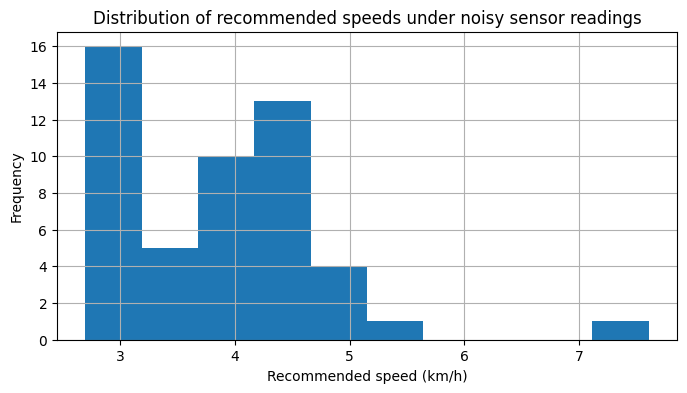

Mean recommended speed: 3.91 km/h
Standard deviation: 0.90 km/h


In [16]:
rng = np.random.default_rng(42)

true_visibility = 60
true_distance = 5
true_battery = 70

noisy_results = []

for _ in range(50):
    measured_visibility = np.clip(rng.normal(true_visibility, 8), 0, 100)
    measured_distance = np.clip(rng.normal(true_distance, 0.8), 0, 10)
    measured_battery = np.clip(rng.normal(true_battery, 5), 0, 100)

    crisp, _, _ = mamdani_robot_speed(
        measured_visibility,
        measured_distance,
        measured_battery,
        verbose=False
    )

    noisy_results.append(crisp)

plt.figure(figsize=(8, 4))
plt.hist(noisy_results, bins=10)
plt.title("Distribution of recommended speeds under noisy sensor readings")
plt.xlabel("Recommended speed (km/h)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

print(f"Mean recommended speed: {np.mean(noisy_results):.2f} km/h")
print(f"Standard deviation: {np.std(noisy_results):.2f} km/h")

## 15. Discussion questions

Answer the following questions in your lab report.

1. Why is a fuzzy rule-based system useful in uncertain environments?
2. What is the role of membership functions?
3. What does it mean for a rule to be partially activated?
4. Why does Mamdani inference need an aggregation step?
5. Why is defuzzification necessary?
6. What are the limitations of this system?
7. How could this system be validated in a real robotic application?

## 16. Short report structure

Your report should contain:

1. **Problem description**  
   Describe the robot speed recommendation problem.

2. **Input and output variables**  
   List the universes of discourse and fuzzy sets.

3. **Rule base**  
   Present the rules and explain the intuition behind at least three of them.

4. **Mamdani inference mechanism**  
   Explain fuzzification, rule activation, implication, aggregation, and defuzzification.

5. **Experiments**  
   Test at least five input scenarios.

6. **Critical analysis**  
   Discuss where the system behaves well and where it behaves poorly.

7. **Possible improvements**  
   Suggest better membership functions, additional inputs, or rule tuning methods.